In [3]:
import pandas as pd
import numpy as np


In [4]:
path_trainset =  r'C:\Users\narma\Dropbox\datasets_edvancer_project\bank_problem\bank-full_train.csv'
train_data = pd.read_csv(path_trainset)

In [5]:
train_data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,ID,y
0,45,blue-collar,married,secondary,no,2,no,no,cellular,26,aug,105,10,-1,0,unknown,22944,no
1,34,admin.,divorced,secondary,no,0,no,no,cellular,10,jul,268,1,-1,0,unknown,13870,no
2,40,technician,divorced,secondary,no,311,no,no,cellular,6,aug,738,2,-1,0,unknown,19301,yes
3,58,self-employed,married,tertiary,no,5810,no,no,cellular,12,mar,139,1,-1,0,unknown,31334,yes
4,59,blue-collar,married,secondary,no,169,yes,no,unknown,16,may,181,3,-1,0,unknown,3849,no


In [6]:
train_data['ID'].nunique()

31647

In [7]:
train_data = train_data.drop('ID', axis=1)

In [8]:
train_data.shape

(31647, 17)

In [9]:
#missing values
train_data.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [10]:
## target variable distribution
train_data['y'].value_counts(normalize =True)*100 
# shows the dataset is imbalanced 

y
no     88.245331
yes    11.754669
Name: proportion, dtype: float64

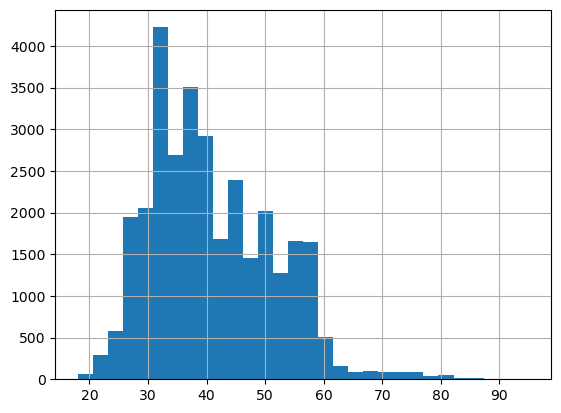

In [11]:
## EDA 
## age distribution
import matplotlib.pyplot as plt
train_data['age'].hist(bins=30)
plt.show()

In [12]:
## create age group
train_data["age_group"] = pd.cut(
    train_data["age"],
    bins=[18,30,40,50,60,100],
    labels = ['18-20','31-40','41-50','51-60','60+']
   )

In [13]:
train_data['age_group'].value_counts()

age_group
31-40    12454
41-50     7774
51-60     5654
18-20     4927
60+        830
Name: count, dtype: int64

In [14]:
age_yes_rate = pd.crosstab(train_data["age_group"],train_data["y"],normalize='index')*100
age_yes_rate.sort_values('yes',ascending=False)

y,no,yes
age_group,,
60+,57.108434,42.891566
18-20,83.458494,16.541506
51-60,89.759462,10.240538
31-40,89.938975,10.061025
41-50,90.841266,9.158734


<function matplotlib.pyplot.show(close=None, block=None)>

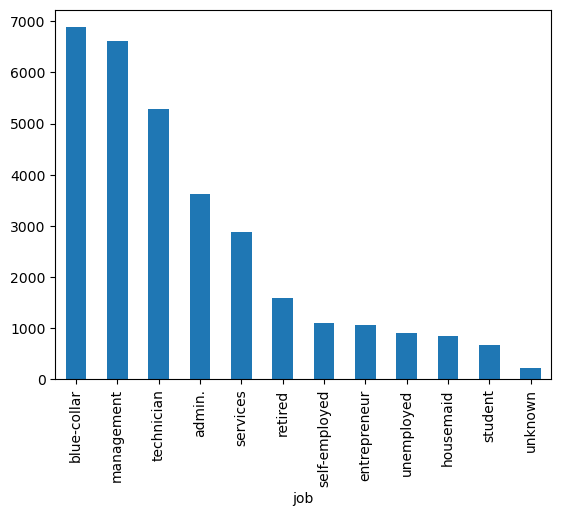

In [15]:
## job 
train_data["job"].value_counts().plot(kind='bar')
plt.show

In [16]:
job_yes_rate = pd.crosstab(
    train_data["job"],
    train_data["y"],
    normalize='index'
)*100
job_yes_rate.sort_values('yes',ascending=False)

y,no,yes
job,,
student,70.757576,29.242424
retired,76.811594,23.188406
unemployed,85.144124,14.855876
management,86.260580,13.739420
admin.,87.862069,12.137931
self-employed,87.889908,12.110092
unknown,88.151659,11.848341
technician,88.613111,11.386889
entrepreneur,90.675547,9.324453


Age group 18-20, 60+ has more yes subscription and employment status proves this with student and retired also has more subscription.

In [17]:
## Feature enginerring
train_data["balance_group"] = pd.qcut(
    train_data['balance'],
    q=4,
    labels=['Low','Medium','High','Very High']
)

In [18]:
train_data['contact_intensity'] = (
   train_data['campaign'] +
    train_data['previous']
)

In [19]:
train_data['campaign_efficiency'] = (
   train_data['duration'] /
    train_data['campaign'] + 1)


In [20]:
train_data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,...,duration,campaign,pdays,previous,poutcome,y,age_group,balance_group,contact_intensity,campaign_efficiency
0,45,blue-collar,married,secondary,no,2,no,no,cellular,26,...,105,10,-1,0,unknown,no,41-50,Low,10,11.500000
1,34,admin.,divorced,secondary,no,0,no,no,cellular,10,...,268,1,-1,0,unknown,no,31-40,Low,1,269.000000
2,40,technician,divorced,secondary,no,311,no,no,cellular,6,...,738,2,-1,0,unknown,yes,31-40,Medium,2,370.000000
3,58,self-employed,married,tertiary,no,5810,no,no,cellular,12,...,139,1,-1,0,unknown,yes,51-60,Very High,1,140.000000
4,59,blue-collar,married,secondary,no,169,yes,no,unknown,16,...,181,3,-1,0,unknown,no,51-60,Medium,3,61.333333


In [21]:
## Train_test split
from sklearn.model_selection import train_test_split

X = train_data.drop('y', axis=1)
y = train_data['y']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y ## because y is imbalanced
)

In [22]:
## lib for building pipelines
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler 

In [23]:
## seperate dtypes columns 
categorical_cols = X.select_dtypes(
    include=['object','category']     ## age_group , balance_group are cateogrt datatypes
).columns

numerical_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns

In [24]:
## preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_cols
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_cols
        )
    ]
)

In [25]:
from sklearn.ensemble import RandomForestClassifier

In [26]:
## Random forest 
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        
    ))
])

In [27]:
## train the model
pipeline.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [28]:
preds = pipeline.predict(X_test)

In [29]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

          no       0.92      0.97      0.95      5586
         yes       0.65      0.40      0.50       744

    accuracy                           0.90      6330
   macro avg       0.79      0.69      0.72      6330
weighted avg       0.89      0.90      0.89      6330



In [31]:
## Logistic regression
from sklearn.linear_model import LogisticRegression

log_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',
     LogisticRegression(
         max_iter=1000
     ))
])

log_model.fit(X_train,y_train)

pred_log = log_model.predict(X_test)

print(classification_report(y_test,pred_log))

              precision    recall  f1-score   support

          no       0.92      0.97      0.95      5586
         yes       0.64      0.37      0.47       744

    accuracy                           0.90      6330
   macro avg       0.78      0.67      0.71      6330
weighted avg       0.89      0.90      0.89      6330



In [32]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [33]:
## Xgboost
from xgboost import XGBClassifier

# convert target to 0/1
y_train_xgb = y_train.map({'no':0,'yes':1})
y_test_xgb = y_test.map({'no':0,'yes':1})

xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',
     XGBClassifier(
         n_estimators=200,
         learning_rate=0.05,
         max_depth=5,
         random_state=42,
         eval_metric='logloss'
     ))
])

xgb_model.fit(X_train,y_train_xgb)

pred_xgb = xgb_model.predict(X_test)

print(classification_report(y_test_xgb,pred_xgb))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      5586
           1       0.65      0.46      0.54       744

    accuracy                           0.91      6330
   macro avg       0.79      0.72      0.75      6330
weighted avg       0.90      0.91      0.90      6330



In [34]:
## get feature importance
xgb_classifier = xgb_model.named_steps['classifier']

feature_names = (
    xgb_model.named_steps['preprocessor']
    .get_feature_names_out()
)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_classifier.feature_importances_
})

importance_df = importance_df.sort_values(
    'Importance',
    ascending=False
)

print(importance_df.head(20))

                     Feature  Importance
51     cat__poutcome_success    0.160351
36      cat__contact_unknown    0.123755
3              num__duration    0.076790
30           cat__housing_no    0.051234
44            cat__month_mar    0.041210
47            cat__month_oct    0.035776
43            cat__month_jun    0.035616
8   num__campaign_efficiency    0.028617
32              cat__loan_no    0.023574
10      cat__job_blue-collar    0.023139
37            cat__month_apr    0.022570
40            cat__month_feb    0.019080
48            cat__month_sep    0.017964
42            cat__month_jul    0.016760
5                 num__pdays    0.015688
46            cat__month_nov    0.015179
41            cat__month_jan    0.013644
45            cat__month_may    0.013020
0                   num__age    0.012714
39            cat__month_dec    0.011259


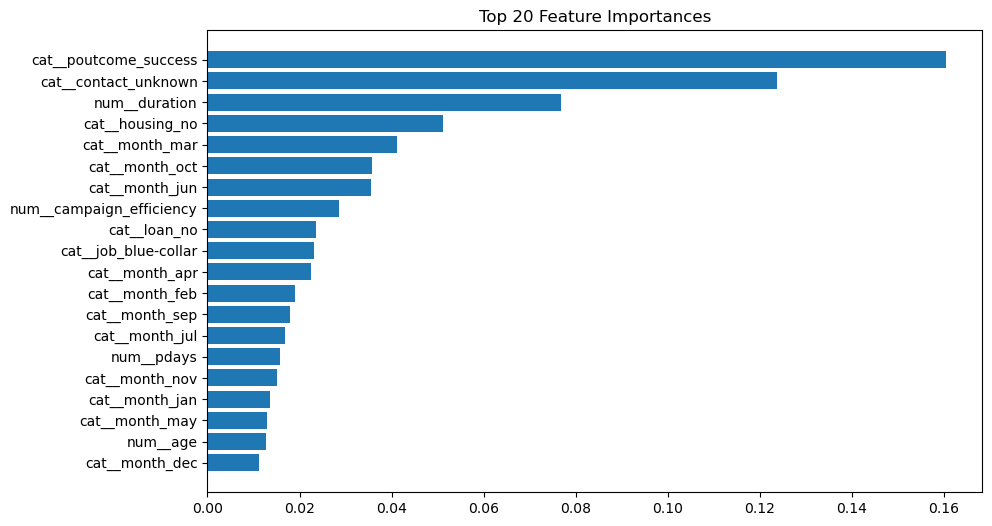

In [35]:
top20 = importance_df.head(20)

plt.figure(figsize=(10,6))

plt.barh(
    top20['Feature'],
    top20['Importance']
)

plt.gca().invert_yaxis()

plt.title('Top 20 Feature Importances')
plt.show()

In [38]:
from sklearn.metrics import roc_curve


y_prob = xgb_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test_xgb, y_prob)

ks = np.max(tpr - fpr)

print("KS Score:", round(ks*100,2))

KS Score: 72.05


In [39]:
from sklearn.metrics import roc_auc_score

y_prob = xgb_model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test_xgb, y_prob)

print("ROC AUC:", round(auc,4))


ROC AUC: 0.9291


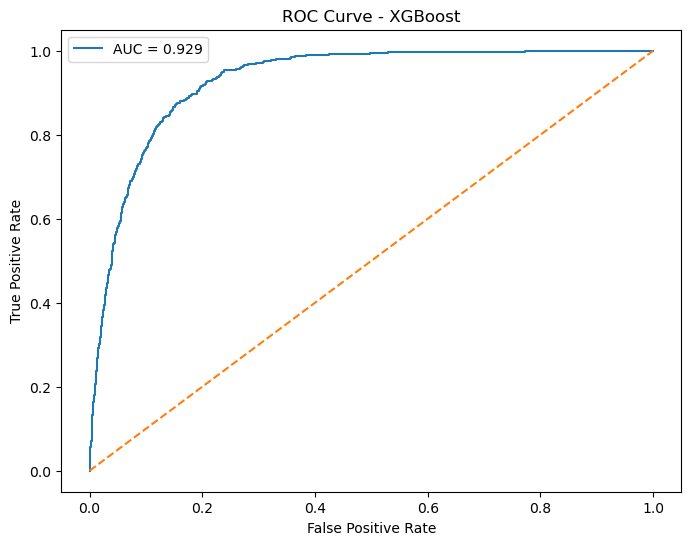

In [40]:
## roc curve
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = xgb_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test_xgb, y_prob)
auc = roc_auc_score(y_test_xgb, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend()

plt.savefig('../outputs/figures/roc_curve.png',
            bbox_inches='tight')

plt.show()

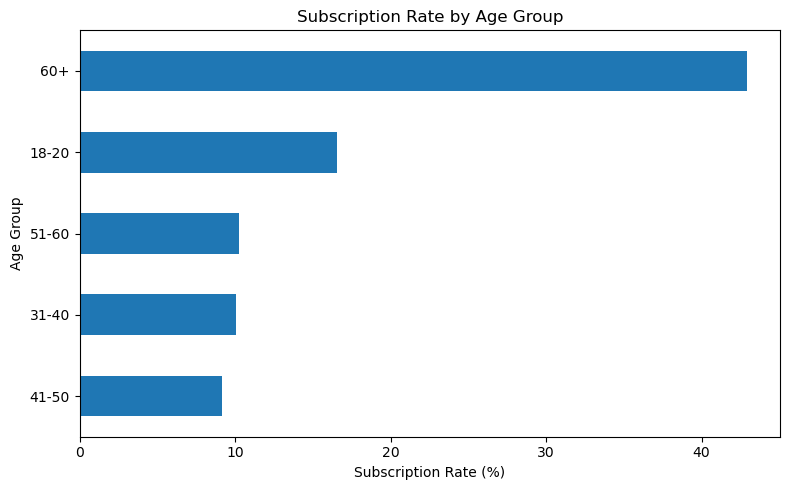

In [41]:
## age group conversion 
age_conversion = pd.crosstab(
    train_data['age_group'],
    train_data['y'],
    normalize='index'
) * 100

age_conversion['yes'].sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.xlabel('Subscription Rate (%)')
plt.ylabel('Age Group')
plt.title('Subscription Rate by Age Group')

plt.tight_layout()
plt.savefig(
    '../outputs/figures/age_group_conversion.png',
    bbox_inches='tight'
)
plt.show()

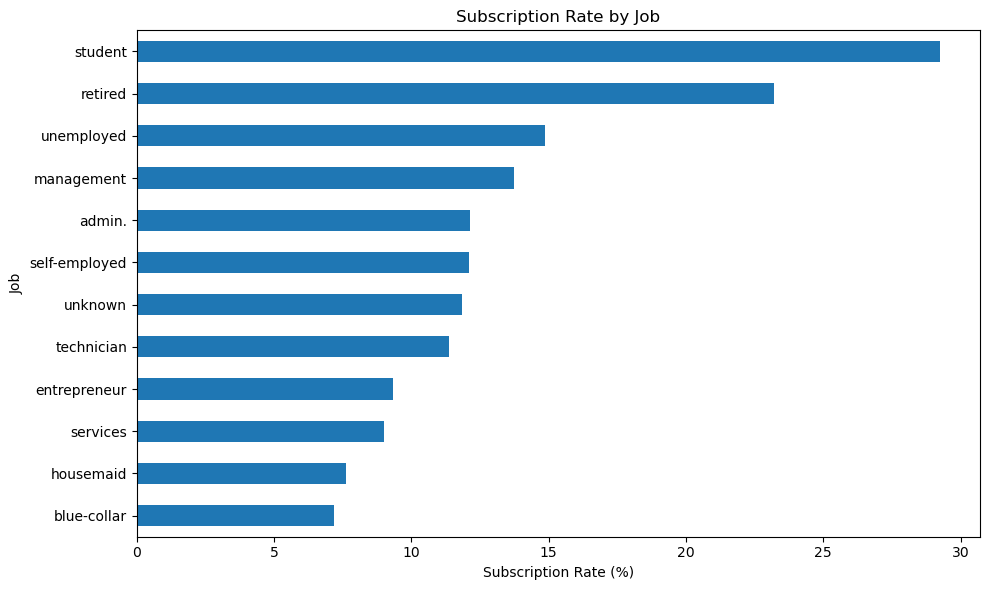

In [42]:
## job conversion rate
job_conversion = pd.crosstab(
    train_data['job'],
    train_data['y'],
    normalize='index'
) * 100

job_conversion['yes'].sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.xlabel('Subscription Rate (%)')
plt.ylabel('Job')
plt.title('Subscription Rate by Job')

plt.tight_layout()
plt.savefig(
    '../outputs/figures/job_conversion.png',
    bbox_inches='tight'
)
plt.show()

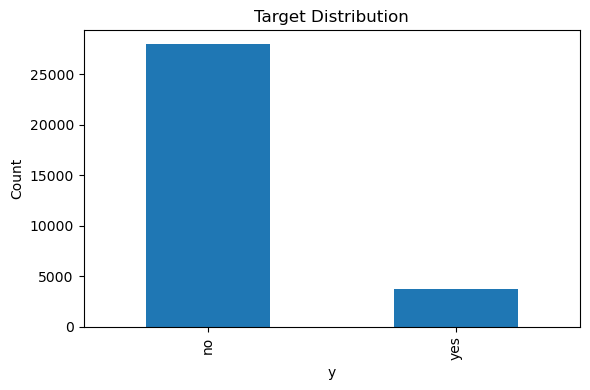

In [45]:
## target distribution train_data['y'].value_counts().plot(
train_data['y'].value_counts().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Target Distribution')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig(
    '../outputs/figures/target_distribution.png',
    bbox_inches='tight'
)
plt.show()

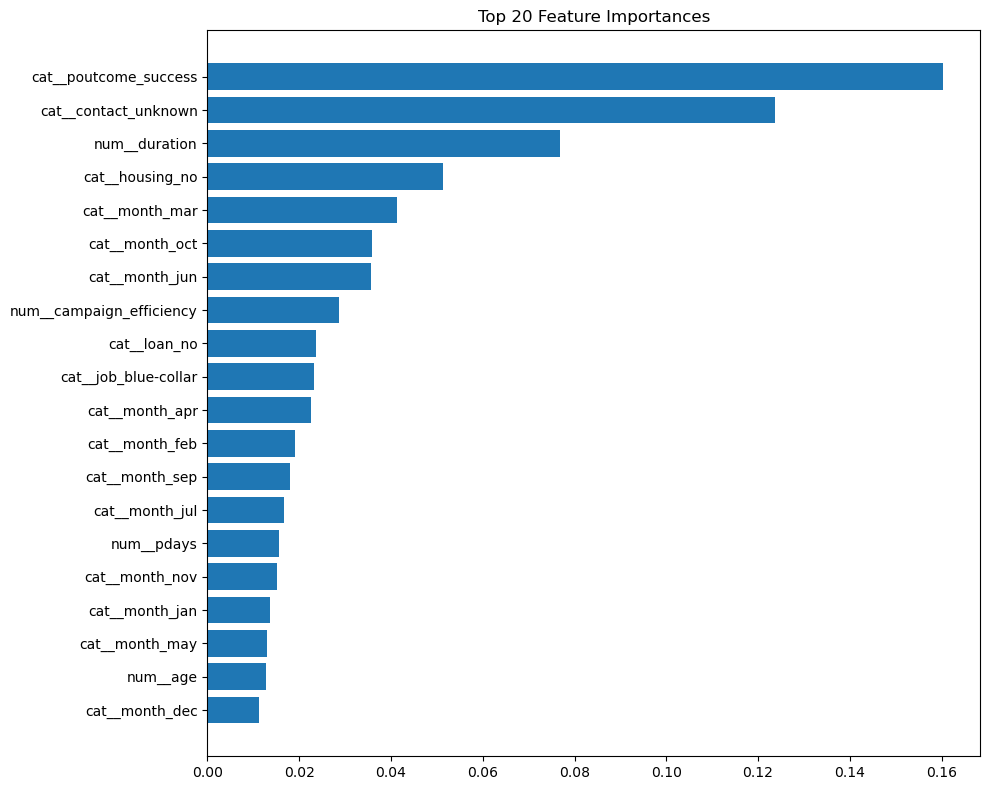

In [46]:
## feature importance
import pandas as pd
import matplotlib.pyplot as plt

feature_names = (
    xgb_model.named_steps['preprocessor']
    .get_feature_names_out()
)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.named_steps[
        'classifier'
    ].feature_importances_
})

top20 = (
    importance_df
    .sort_values('Importance', ascending=False)
    .head(20)
)

plt.figure(figsize=(10,8))

plt.barh(
    top20['Feature'][::-1],
    top20['Importance'][::-1]
)

plt.title('Top 20 Feature Importances')

plt.tight_layout()

plt.savefig(
    '../outputs/figures/feature_importance.png',
    bbox_inches='tight'
)

plt.show()